# FARSITE Fire Spread Simulation

Runs a FARSITE fire spread simulation from a user-defined ignition point,
producing one perimeter prediction every 30 minutes for 4 hours.

**Pipeline:**
1. Install dependencies
2. Import libraries and configure paths
3. Define ignition location and fire weather parameters
4. Build and reproject the initial ignition polygon
5. Run FARSITE iteratively to collect perimeters over time
6. Plot perimeter progression with area growth statistics
7. Export perimeters to GeoJSON

## 1. Install Dependencies

Installs required system and Python packages via `install_packages.sh`.

This takes up to 5 minutes to completion, and only needs to be run once per environment.

In [ ]:
!chmod +x install_packages.sh farsite/TestFARSITE
!./install_packages.sh

## 2. Imports and Environment Setup

In [1]:
import sys
import io
import os
from pathlib import Path
import numpy as np
import pandas as pd

import geopandas as gpd
import json
from geojson import Feature, FeatureCollection
from datetime import datetime, timedelta
from shapely.geometry import Polygon, shape
from shapely.ops import transform as shp_transform
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from pyproj import Transformer
import contextily as ctx
import rasterio
from rasterio.mask import mask
from osgeo import gdal, osr

gdal.UseExceptions()
osr.UseExceptions()

# set working directory to notebook location so all relative paths resolve correctly
os.chdir(Path(os.path.abspath('')))
print(f'Working directory: {Path.cwd()}')

# add farsite/ to path and import the simulation wrapper
sys.path.insert(0, 'farsite')
from farsite import forward_pass_farsite, run_farsite_continuous

print('Imports OK.')

Working directory: /home/jovyan/work/Fire_Risk_Scenario
Imports OK.


In [2]:
# resolve all paths as absolute so FARSITE receives correct locations
# regardless of working directory changes
BASE_DIR     = Path(os.path.abspath(''))
FARSITE_DIR  = BASE_DIR / 'farsite'
TIFF_DIR       = BASE_DIR / 'Forest'
LCP_FILEPATH = BASE_DIR / 'Forest_LCP_Outputs' / 'landscape.lcp'

print(f'FARSITE executable: {FARSITE_DIR / "TestFARSITE"}')
print(f'Landscape file:     {LCP_FILEPATH}')
print(f'LCP exists:         {LCP_FILEPATH.exists()}')

FARSITE executable: /home/jovyan/work/Fire_Risk_Scenario/farsite/TestFARSITE
Landscape file:     /home/jovyan/work/Fire_Risk_Scenario/Forest_LCP_Outputs/landscape.lcp
LCP exists:         True


## 3. Simulation Parameters

All user-configurable settings are defined here.

| Parameter | Description |
|---|---|
| `IGNITION_LAT/LON` | WGS84 coordinates of the ignition point |
| `START_TIME` | Simulation start time (YYYY-MM-DD HH:MM:SS) |
| `WIND_SPEED` | Wind speed (mph) |
| `WIND_DIRECTION` | Wind direction as a vector azimuth (degrees) |
| `TOTAL_HOURS` | Total simulation duration (hours) |
| `STEP_MINUTES` | Interval between perimeter snapshots (minutes) |
| `DISTANCE_RES` | FARSITE distance resolution (metres) |
| `PERIMETER_RES` | FARSITE perimeter resolution (metres) |

In [18]:
# ignition location (WGS84)
IGNITION_LAT = 38.9162145
IGNITION_LON = -120.026655

# simulation timing
START_TIME   = '2026-03-16 14:10:00'
TOTAL_HOURS  = 4
STEP_MINUTES = 30

# fire weather
WIND_SPEED     = 15    # mph
WIND_DIRECTION = 236   # degrees azimuth
TEMPERATURE = 90
HUMIDITY = 10

# FARSITE spatial resolution
DISTANCE_RES  = 60    # 60 metres
PERIMETER_RES = 60    # 60 metres


n_steps = (TOTAL_HOURS * 60) // STEP_MINUTES
print(f'Ignition:   ({IGNITION_LON}, {IGNITION_LAT})')
print(f'Start time: {START_TIME}')
print(f'Duration:   {TOTAL_HOURS} hours  ({n_steps} steps x {STEP_MINUTES} min)')

Ignition:   (-120.026655, 38.9162145)
Start time: 2026-03-16 14:10:00
Duration:   4 hours  (8 steps x 30 min)


In [19]:
# Calculate RAWS_ELEVATION
ds = gdal.Open(str(LCP_FILEPATH))
gt = ds.GetGeoTransform()

# ignition in EPSG:5070
t = Transformer.from_crs('EPSG:4326', 'EPSG:5070', always_xy=True)
ig_x, ig_y = t.transform(IGNITION_LON, IGNITION_LAT)

col = int((ig_x - gt[0]) / gt[1])
row = int((ig_y - gt[3]) / gt[5])

elev_m  = ds.GetRasterBand(1).ReadAsArray(col, row, 1, 1)[0, 0]
ds      = None

RAWS_ELEVATION = int(elev_m * 3.28084)  # convert metres -> feet
print(f'Elevation at ignition: {elev_m:.0f}m = {RAWS_ELEVATION}ft')

Elevation at ignition: 1911m = 6269ft


## 4. Build Initial Ignition Polygon

FARSITE requires a polygon rather than a point as its ignition input.
A small square (~30m across) is created around the ignition coordinate,
then reprojected from WGS84 to EPSG:5070 (NAD83 / Conus Albers, metres)
to match the LCP projection.

In [20]:
def reproject_polygon(poly, from_epsg, to_epsg):
    """Reproject a Shapely polygon between two CRS using pyproj."""
    transformer = Transformer.from_crs(from_epsg, to_epsg, always_xy=True)
    return shp_transform(transformer.transform, poly)

# create a small square around the ignition point in WGS84
# offset of 0.00015 degrees ≈ 15 metres at this latitude
offset = 0.00015
farsite_poly = Polygon([
    [IGNITION_LON - offset, IGNITION_LAT - offset],
    [IGNITION_LON + offset, IGNITION_LAT - offset],
    [IGNITION_LON + offset, IGNITION_LAT + offset],
    [IGNITION_LON - offset, IGNITION_LAT + offset],
    [IGNITION_LON - offset, IGNITION_LAT - offset],
])

# reproject to EPSG:5070 — required because the LCP is in Conus Albers metres
# and farsite.py writes the ignition shapefile with crs=EPSG:5070
farsite_poly_projected = reproject_polygon(farsite_poly, 'EPSG:4326', 'EPSG:5070')

print(f'Ignition polygon bounds (EPSG:5070): {farsite_poly_projected.bounds}')

Ignition polygon bounds (EPSG:5070): (-2042005.7398692707, 2025015.2258255095, -2041972.377949079, 2025054.2281156986)


# Set FARSITE parameters

In [21]:
farsite_params = {
    'windspeed':     WIND_SPEED,
    'winddirection': WIND_DIRECTION,
    'dt':            timedelta(minutes=STEP_MINUTES),
}

# state variables updated each iteration
ignition_poly = farsite_poly_projected
SIMULATION_START = pd.to_datetime(START_TIME, format='%Y-%m-%d %H:%M:%S')

# results: list of (elapsed_minutes, Shapely Polygon in EPSG:5070)
perimeters = []

### Define function to sample fuel moisture

In [22]:
def sample_moisture_rasters(ignition_poly, raster_dir, prefix="Forest", crs="EPSG:5070"):
    """
    Sample 1hr fuel moisture from rasters and derive 10hr/100hr via
    standard Nelson timelag ratios (2x, 3x).

    Reads:
      - {prefix}_moist1.tif  (1hr moisture, decimal fraction)
      - {prefix}_rhof1.tif   (1hr fuel loading, kg/m², used as weight)

    Returns a fuel_moistures tuple: (0, fm1, fm10, fm100, herb, woody)
    """
    raster_dir = Path(raster_dir)
    ignition_gdf = gpd.GeoDataFrame(geometry=[ignition_poly], crs=crs)

    def sample_raster(tif_path):
        """Return flat array of valid pixel values clipped to ignition polygon."""
        with rasterio.open(tif_path) as src:
            geom_gdf = ignition_gdf.to_crs(src.crs) if src.crs else ignition_gdf
            geom     = [mapping(geom_gdf.geometry.iloc[0])]
            out, _   = rasterio.mask.mask(src, geom, crop=True, nodata=np.nan)
            data     = out[0].astype(float)
            if src.nodata is not None:
                data[data == src.nodata] = np.nan
            return data[np.isfinite(data)]

    # --- 1hr moisture (decimal) weighted by 1hr fuel loading (kg/m²) ---
    moist1_vals = sample_raster(raster_dir / f'{prefix}_moist1.tif')
    rhof1_vals  = sample_raster(raster_dir / f'{prefix}_rhof1.tif')

    # align array sizes (should match since they share the same grid)
    n = min(len(moist1_vals), len(rhof1_vals))
    if n == 0:
        raise ValueError('No valid pixels under ignition polygon')

    moist1_vals = moist1_vals[:n]
    rhof1_vals  = rhof1_vals[:n]

    weights = np.clip(rhof1_vals, 0, None)
    total_w = weights.sum()

    if total_w > 0:
        fm1_dec = float(np.average(moist1_vals, weights=weights))
    else:
        fm1_dec = float(np.mean(moist1_vals))

    # convert decimal -> integer percent
    fm1 = int(round(fm1_dec * 100 if fm1_dec <= 1.0 else fm1_dec))

    # --- 10hr and 100hr: standard Nelson timelag ratios (2x, 3x) ---
    fm10  = int(round(fm1 * 2.0))
    fm100 = int(round(fm1 * 3.0))

    print(f'  fm1  (loading-weighted): {fm1}%')
    print(f'  fm10 (2x Nelson ratio):  {fm10}%')
    print(f'  fm100 (3x Nelson ratio): {fm100}%')
    print(f'  rhof1 mean loading:      {rhof1_vals.mean():.4f} kg/m²')

    return (0, fm1, fm10, fm100, 60, 60)


In [23]:
# sample fuel moisture rasters over the ignition polygon
# returns a (fuel_model, fm1, fm10, fm100, herb, woody) tuple ready for FARSITE
print('Sampling fuel moisture rasters over ignition polygon...')
fuel_moistures = sample_moisture_rasters(
    ignition_poly=ignition_poly,
    raster_dir=TIFF_DIR,
    prefix='Forest',
)
print(f'\nfuel_moistures: {fuel_moistures}')

Sampling fuel moisture rasters over ignition polygon...
  fm1  (loading-weighted): 4%
  fm10 (2x Nelson ratio):  8%
  fm100 (3x Nelson ratio): 12%
  rhof1 mean loading:      0.3587 kg/m²

fuel_moistures: (0, 4, 8, 12, 60, 60)


## 5. Run FARSITE 

Runs FARSITE with advancement intervals of `STEP_MINUTES`, where each step's output perimeter becomes the ignition polygon for the next step,
allowing the fire to grow continuously over the simulation period.

In [24]:
from farsite import MAX_FARSITE_TIMESTEP, validate_geom

# Run a SINGLE continuous 4-hour FARSITE simulation.
# 30-min FARSITE intervals — the fire accelerates once at ignition
# and spreads at equilibrium rate for the rest of the simulation.

continuous_params = {
    'windspeed':     WIND_SPEED,
    'winddirection': WIND_DIRECTION,
    'dt':            timedelta(hours=TOTAL_HOURS),
}

print(f'Running single continuous {TOTAL_HOURS}-hour FARSITE simulation...')
print(f'  Internal timestep: {MAX_FARSITE_TIMESTEP} min → {n_steps} intermediate perimeters\n')

all_polys = run_farsite_continuous(
    ignition_poly,
    continuous_params,
    SIMULATION_START,
    str(LCP_FILEPATH),
    dist_res=DISTANCE_RES,
    perim_res=PERIMETER_RES,
    fuel_moistures=fuel_moistures,
    temperature=TEMPERATURE,
    humidity=HUMIDITY,
    raws_elevation=RAWS_ELEVATION,
    debug=False,
)

if all_polys is None:
    print('FAILED — no perimeters produced')
else:
    # Build perimeters list: (elapsed_minutes, polygon)
    for idx, poly in enumerate(all_polys):
        elapsed_min = (idx + 1) * MAX_FARSITE_TIMESTEP
        perimeters.append((elapsed_min, validate_geom(poly)))
        print(f'  Perimeter {idx+1}: t={elapsed_min} min  area={poly.area/1e6:.4f} km²')

    print(f'\nDone — {len(perimeters)} perimeters collected')

Running single continuous 4-hour FARSITE simulation...
  Internal timestep: 30 min → 8 intermediate perimeters

  Perimeter 1: t=30 min  area=0.0891 km²
  Perimeter 2: t=60 min  area=0.2152 km²
  Perimeter 3: t=90 min  area=0.3062 km²
  Perimeter 4: t=120 min  area=0.3692 km²
  Perimeter 5: t=150 min  area=0.4439 km²
  Perimeter 6: t=180 min  area=0.5001 km²
  Perimeter 7: t=210 min  area=0.5395 km²
  Perimeter 8: t=240 min  area=0.5872 km²
  Perimeter 9: t=270 min  area=0.6338 km²

Done — 9 perimeters collected


In [25]:
# convert perimeters from EPSG:5070 to WGS84 for plotting and export
def to_wgs84(poly):
    """Reproject a Shapely polygon from EPSG:5070 to WGS84."""
    t = Transformer.from_crs('EPSG:5070', 'EPSG:4326', always_xy=True)
    return shp_transform(t.transform, poly)

perimeters_gdf = gpd.GeoDataFrame(
    [{'elapsed_min': t, 'geometry': to_wgs84(p)} for t, p in perimeters],
    crs='EPSG:4326',
)

print(perimeters_gdf[['elapsed_min', 'geometry']].to_string())

   elapsed_min                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## 6. Plot Perimeter Progression and Area Growth

Plots each perimeter on a basemap, colored from yellow (earliest) to red (latest).
Area growth statistics are printed below the map.

In [26]:
# area growth statistics
# note: area must be computed in a projected CRS (EPSG:5070, metres)
# not in WGS84 degrees, which would give meaningless values
print(f'{"Step":>5}  {"Elapsed (min)":>14}  {"Area (km²)":>12}  {"Growth (km²)":>13}  {"Growth (%)":>10}')
print('-' * 62)

prev_area = 0
for i, row in perimeters_gdf.iterrows():
    poly_proj  = reproject_polygon(row.geometry, 'EPSG:4326', 'EPSG:5070')
    area_km2   = poly_proj.area / 1e6
    growth_km2 = area_km2 - prev_area
    growth_pct = (growth_km2 / prev_area * 100) if prev_area > 0 else 0
    print(f'{i+1:>5}  {row["elapsed_min"]:>14}  {area_km2:>12.4f}  {growth_km2:>13.4f}  {growth_pct:>9.1f}%')
    prev_area = area_km2

# compute total growth from step 1 to final step
first_area = reproject_polygon(perimeters_gdf.iloc[0].geometry, 'EPSG:4326', 'EPSG:5070').area / 1e6
print(f'\nFinal area:   {prev_area:.4f} km²')
print(f'Total growth: {prev_area - first_area:.4f} km²')

 Step   Elapsed (min)    Area (km²)   Growth (km²)  Growth (%)
--------------------------------------------------------------
    1              30        0.0891         0.0891        0.0%
    2              60        0.2152         0.1262      141.6%
    3              90        0.3062         0.0910       42.3%
    4             120        0.3692         0.0630       20.6%
    5             150        0.4439         0.0746       20.2%
    6             180        0.5001         0.0562       12.7%
    7             210        0.5395         0.0394        7.9%
    8             240        0.5872         0.0478        8.9%
    9             270        0.6338         0.0465        7.9%

Final area:   0.6338 km²
Total growth: 0.5447 km²


In [27]:
perimeters_gdf = gpd.GeoDataFrame(
    [{'elapsed_min': t, 'geometry': to_wgs84(p)} for t, p in perimeters],
    crs='EPSG:4326',
)

In [28]:
OUTPUT_DIR = Path('fire_output_geojsons')
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / 'perimeters.geojson'

In [29]:
# load buildings and roads (both in WGS84)
buildings_gdf = gpd.read_file(TIFF_DIR / 'Forest_generated_buildings_fireprops.json')
roads_gdf     = gpd.read_file(TIFF_DIR / 'Forest_roads.json')

print(f'Buildings: {len(buildings_gdf)} features')
print(f'Roads:     {len(roads_gdf)} features')

Buildings: 4498 features
Roads:     1205 features


In [30]:
def plot_perimeters(perimeters_gdf, buildings_gdf=None, roads_gdf=None,
                    title='Fire Perimeter Progression'):
    """
    Plot fire perimeters over a basemap, colored by elapsed time.
    Optionally overlays building footprints and road network.

    Parameters
    ----------
    perimeters_gdf : GeoDataFrame  — WGS84, columns: elapsed_min, geometry
    buildings_gdf  : GeoDataFrame  — WGS84 building footprints (optional)
    roads_gdf      : GeoDataFrame  — WGS84 road network (optional)
    title          : str
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    # --- roads (draw first so perimeters sit on top) ---
    if roads_gdf is not None:
        roads_gdf.plot(
            ax=ax,
            color='#888888',
            linewidth=0.8,
            alpha=0.7,
            zorder=2,
        )

    # --- fire perimeters ---
    n      = len(perimeters_gdf)
    colors = cm.YlOrRd(np.linspace(0.2, 1.0, n))

    for i, row in perimeters_gdf.iterrows():
        geom  = row.geometry
        color = colors[i]
        polys = geom.geoms if geom.geom_type == 'MultiPolygon' else [geom]
        for poly in polys:
            x, y = poly.exterior.xy
            ax.fill(x, y, alpha=0.25, color=color, zorder=3)
            ax.plot(x, y, color=color, linewidth=1.5, zorder=3)

    # --- buildings (draw on top of perimeters so they stay visible) ---
    if buildings_gdf is not None:
        buildings_gdf.plot(
            ax=ax,
            color='#2166ac',
            edgecolor='#0d3e6e',
            linewidth=0.5,
            alpha=0.7,
            zorder=4,
        )

    # --- ignition point ---
    ax.plot(IGNITION_LON, IGNITION_LAT, 'r*', markersize=12, zorder=5)

    # --- basemap ---
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs='EPSG:4326')

    # --- legend ---
    legend_patches = [
        mpatches.Patch(color=colors[i], label=f"{row['elapsed_min']} min")
        for i, row in perimeters_gdf.iterrows()
    ]
    legend_patches.append(
        plt.Line2D([0], [0], marker='*', color='r', linestyle='None',
                   markersize=10, label='Ignition')
    )
    if roads_gdf is not None:
        legend_patches.append(
            plt.Line2D([0], [0], color='#888888', linewidth=1.5, label='Roads')
        )
    if buildings_gdf is not None:
        legend_patches.append(
            mpatches.Patch(color='#2166ac', label='Buildings')
        )
    ax.legend(handles=legend_patches, title='Legend',
              loc='upper left', fontsize=9)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig('fire_perimeters.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fire_perimeters.png')

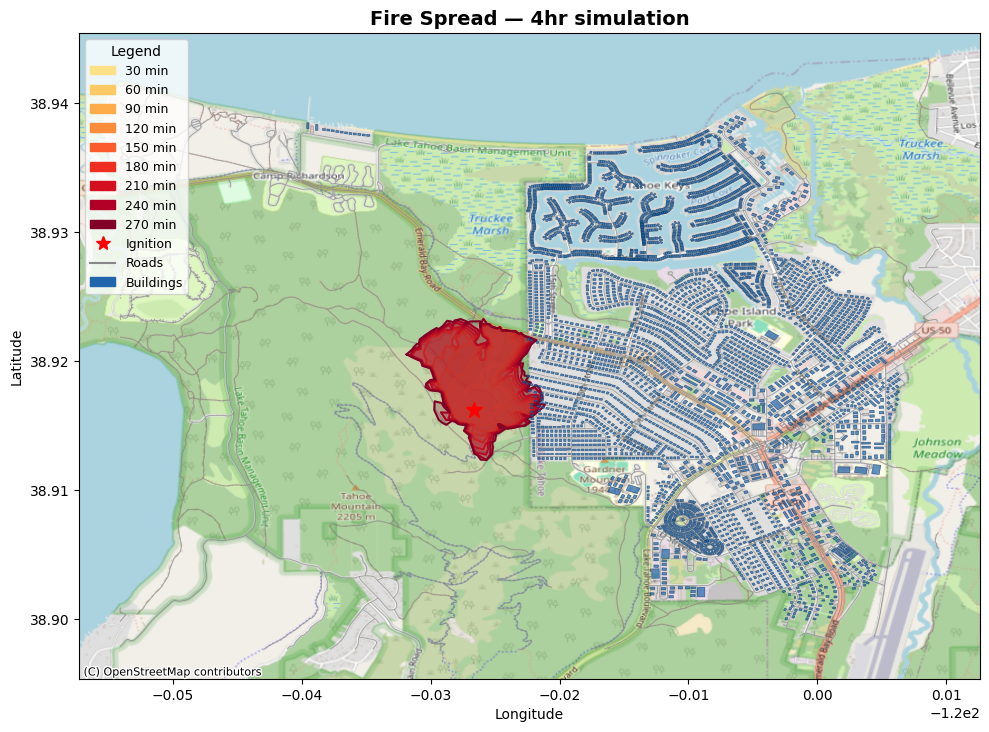

Saved: fire_perimeters.png


In [31]:
plot_perimeters(
    perimeters_gdf,
    buildings_gdf=buildings_gdf,
    roads_gdf=roads_gdf,
    title=f'Fire Spread — {TOTAL_HOURS}hr simulation',
)

## 7. Export Perimeters to GeoJSON

Saves all perimeters as a single GeoJSON file. Each feature includes
an `elapsed_min` property indicating the simulation time.

In [32]:
perimeters_gdf.to_file(str(OUTPUT_PATH), driver='GeoJSON')

print(f'✓ Saved {len(perimeters_gdf)} perimeters to {OUTPUT_PATH}')

✓ Saved 9 perimeters to fire_output_geojsons/perimeters.geojson


## 7. Export Perimeters to ESRI Shapefiles